# DATA WRANGLING

In [565]:
import pandas as pd

jobs_df = pd.read_csv("dataset/jobs.csv")
skills_df = pd.read_csv("dataset/skills.csv")
resume_df = pd.read_csv("dataset/resume.csv")

In [566]:
jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Job Title              324 non-null    object
 1   Category               324 non-null    object
 2   Education Requirement  324 non-null    object
 3   Experience Years       324 non-null    int64 
 4   Required Skills        324 non-null    object
 5   Salary Range           324 non-null    object
dtypes: int64(1), object(5)
memory usage: 15.3+ KB


In [567]:
skills_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Skill Name  120 non-null    object
 1   Category    120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [568]:
resume_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Resume ID         10000 non-null  object
 1   Resume Text       10000 non-null  object
 2   Education         10000 non-null  object
 3   Experience Years  10000 non-null  int64 
 4   Skills            10000 non-null  object
 5   Job Role          10000 non-null  object
 6   Category          10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [569]:
# Normalize semua text (spasi, huruf kapital/kecil)
jobs_df = jobs_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
skills_df = skills_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
resume_df = resume_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)

C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\1157588541.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  jobs_df = jobs_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\1157588541.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  skills_df = skills_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)
C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\1157588541.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  resume_df = resume_df.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [570]:
# Merapikan nama kolom
jobs_df.columns = jobs_df.columns.str.lower().str.replace(" ", "_")
skills_df.columns = skills_df.columns.str.lower().str.replace(" ", "_")
resume_df.columns = resume_df.columns.str.lower().str.replace(" ", "_")

In [571]:
# Cleaning skills (dari resume.csv)
def clean_skills(text):
    text = text.replace("[","").replace("]","").replace("'","")
    skills = text.split(",")
    return [s.strip() for s in skills if s.strip() != ""]

resume_df['skills'] = resume_df['skills'].apply(clean_skills)

In [572]:
# Cleaning skills (dari jobs.csv)
jobs_df['required_skills'] = jobs_df['required_skills'].apply(clean_skills)

In [573]:
# Samakan nama kolom untuk job di jobs.csv dan resume.csv
jobs_df['job_title'] = jobs_df['job_title'].str.strip()
resume_df['job_role'] = resume_df['job_role'].str.strip()

In [574]:
# Cek udah cocok belum (kalau kosong -> job sudah match)
set(resume_df['job_role']) - set(jobs_df['job_title'])

set()

In [575]:
# Normalisasi singkatan jurusan
import re
def clean_education_v2(text):
    text = text.lower()
    
    mapping = {
        "it": "information technology",
        "rn": "nursing",
        "mba": "business administration",
        "mpa": "public administration",
        "hr": "human resources",
        "cpa": "accounting",
        "qa": "quality assurance",
        "ai": "artificial intelligence",
        "pt": "physical therapy"
    }
    
    for k, v in mapping.items():
        text = re.sub(rf'\b{k}\b', v, text)
    
    return text.strip()

resume_df['education_clean_v2'] = resume_df['education'].apply(clean_education_v2)
jobs_df['education_clean_v2'] = jobs_df['education_requirement'].apply(clean_education_v2)

In [576]:
# Drop kolom lama education dan ganti dengan yang baru
resume_df = resume_df.drop(columns=['education'])
resume_df = resume_df.rename(columns={'education_clean_v2': 'education'})

jobs_df = jobs_df.drop(columns=['education_requirement'])
jobs_df = jobs_df.rename(columns={'education_clean_v2': 'education_requirement'})

In [577]:
# Cek apakah sudah terganti
resume_df.head(10)

,resume_id,resume_text,experience_years,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,2,[market research|maven|java|rest api|spring bo...,java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,3,[agile|data analysis|precision|problem solving...,microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,2,[react|customer service|technical knowledge|pl...,plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,0,[mysql|query optimization|symfony|terraform|ph...,php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,3,[problem solving|docker|creativity|scrum|ansib...,art director,creative & design,bachelor's in design
5,r000005,education: administrative certification experi...,2,[ci/cd|problem solving|database design|pytorch...,executive assistant,administration,administrative certification
6,r000006,education: bachelor's in computer science expe...,3,[distributed systems|cql|cassandra|performance...,cassandra developer,technology,bachelor's in computer science
7,r000007,education: bachelor's in it experience: 1 year...,1,[performance tuning|sql|etl|data integration|j...,informatica developer,data & analytics,bachelor's in information technology
8,r000008,education: pt license experience: 4 years skil...,4,[communication|swift|anatomy knowledge|exercis...,physical therapist,healthcare,physical therapy license
9,r000009,education: bachelor's in computer science expe...,5,[postgresql|distributed systems|kanban|phoenix...,elixir developer,technology,bachelor's in computer science


In [578]:
jobs_df.head(10)

,job_title,category,experience_years,required_skills,salary_range,education_requirement
0,software engineer,technology,2,[python|java|c++|git|software design|problem s...,80-150k,bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,2,[javascript|react|node.js|html/css|database|git],75-140k,diploma in information technology|bachelor's i...
2,frontend developer,technology,1,[javascript|react|vue.js|css|html|ui/ux design],70-130k,diploma in information technology|bachelor's i...
3,backend developer,technology,2,[python|java|node.js|database design|api devel...,75-135k,bachelor's in computer science
4,devops engineer,technology,3,[docker|kubernetes|aws|linux|ci/cd|scripting],85-150k,bachelor's in computer science|information tec...
5,cloud architect,technology,5,[aws|azure|gcp|system design|networking|security],120-200k,bachelor's in computer science|cloud certifica...
6,data scientist,technology,2,[python|machine learning|statistics|tensorflow...,90-160k,master's in data science|bachelor's in mathema...
7,machine learning engineer,technology,3,[python|tensorflow|pytorch|deep learning|stati...,100-180k,master's in computer science|master's in artif...
8,data engineer,technology,2,[python|spark|hadoop|sql|data warehousing|etl],85-155k,bachelor's in computer science
9,database administrator,technology,2,[sql|mongodb|database optimization|linux|backu...,70-130k,bachelor's in information technology|informati...


In [579]:
print(jobs_df['required_skills'].iloc[0])
print(type(jobs_df['required_skills'].iloc[0]))

['python|java|c++|git|software design|problem solving']
<class 'list'>


In [580]:
# Cleaning skills
def clean_skills(text):
    import pandas as pd
    
    if pd.isna(text):
        return []
    
    # kalau list
    if isinstance(text, list):
        # kalau list cuma 1 elemen → ambil isinya
        if len(text) == 1:
            text = text[0]
        else:
            return [str(s).strip().lower() for s in text]
    
    # sekarang pasti string
    text = str(text).lower()
    
    text = text.replace("[","").replace("]","")
    text = text.replace("|", ",")
    
    skills = text.split(",")
    
    return [s.strip() for s in skills if s.strip() != ""]

In [581]:
jobs_df['required_skills'] = jobs_df['required_skills'].apply(clean_skills)
resume_df['skills'] = resume_df['skills'].apply(clean_skills)

In [582]:
# Cek apakah sudah berubah jadi list di bagian required skills & skills
jobs_df.head()

,job_title,category,experience_years,required_skills,salary_range,education_requirement
0,software engineer,technology,2,"[python, java, c++, git, software design, prob...",80-150k,bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,2,"[javascript, react, node.js, html/css, databas...",75-140k,diploma in information technology|bachelor's i...
2,frontend developer,technology,1,"[javascript, react, vue.js, css, html, ui/ux d...",70-130k,diploma in information technology|bachelor's i...
3,backend developer,technology,2,"[python, java, node.js, database design, api d...",75-135k,bachelor's in computer science
4,devops engineer,technology,3,"[docker, kubernetes, aws, linux, ci/cd, script...",85-150k,bachelor's in computer science|information tec...


In [583]:
resume_df.head()

,resume_id,resume_text,experience_years,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,2,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,3,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,2,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,0,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,3,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design


In [584]:
# Hapus kolom tidak perlu
jobs_df.drop(columns=['experience_years', 'salary_range'], inplace=True)
resume_df.drop(columns=['experience_years'], inplace=True)

In [585]:
# Cek lagi tabel final
jobs_df.head()

,job_title,category,required_skills,education_requirement
0,software engineer,technology,"[python, java, c++, git, software design, prob...",bachelor's in computer science|bachelor's in e...
1,full stack developer,technology,"[javascript, react, node.js, html/css, databas...",diploma in information technology|bachelor's i...
2,frontend developer,technology,"[javascript, react, vue.js, css, html, ui/ux d...",diploma in information technology|bachelor's i...
3,backend developer,technology,"[python, java, node.js, database design, api d...",bachelor's in computer science
4,devops engineer,technology,"[docker, kubernetes, aws, linux, ci/cd, script...",bachelor's in computer science|information tec...


In [586]:
resume_df.head()

,resume_id,resume_text,skills,job_role,category,education
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design


In [587]:
# Sebelum dimerge, pastikan nama kolom sama
jobs_df['job_title'] = jobs_df['job_title'].str.strip().str.lower()
resume_df['job_role'] = resume_df['job_role'].str.strip().str.lower()

In [588]:
# Cek apakah sudah match apa belum (kosong berarti match)
set(resume_df['job_role']) - set(jobs_df['job_title'])

set()

In [589]:
# Merge tabel
merged_df = resume_df.merge(
    jobs_df,
    left_on='job_role',
    right_on='job_title',
    how='inner'
)

In [590]:
merged_df.head()

,resume_id,resume_text,skills,job_role,category_x,education,job_title,category_y,required_skills,education_requirement
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,technology,bachelor's in computer science,java backend developer,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,science & research,master's in microbiology,microbiologist,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,skilled trades,apprenticeship,plumber,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,technology,bachelor's in computer science,php developer,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,creative & design,bachelor's in design,art director,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [591]:
len(merged_df)

10000

In [592]:
# Pakai kolom category dari 1 dataset saja (supaya tidak jadi x dan y)
merged_df = merged_df.drop(columns=['category_x'])
merged_df = merged_df.rename(columns={'category_y': 'category'})

In [593]:
# Pakai kolom job role saja untuk jadi label (job_title dihapus)
merged_df = merged_df.drop(columns=['job_title'])

In [594]:
# Cek tabel final
merged_df.head()

,resume_id,resume_text,skills,job_role,education,category,required_skills,education_requirement
0,r000000,education: bachelor's in computer science expe...,"[market research, maven, java, rest api, sprin...",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science
1,r000001,education: master's in microbiology experience...,"[agile, data analysis, precision, problem solv...",microbiologist,master's in microbiology,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology
2,r000002,education: apprenticeship experience: 2 years ...,"[react, customer service, technical knowledge,...",plumber,apprenticeship,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship
3,r000003,education: bachelor's in computer science expe...,"[mysql, query optimization, symfony, terraform...",php developer,bachelor's in computer science,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science
4,r000004,education: bachelor's in design experience: 3 ...,"[problem solving, docker, creativity, scrum, a...",art director,bachelor's in design,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design


In [595]:
merged_df.to_csv("cleaned_dataset.csv", index=False)

## FEATURE ENGINEERING

### Pisahkan soft skill & hard skill

In [596]:
# Soft skills (lebih lengkap & umum)
soft_skills_set = {
    'communication', 'teamwork', 'leadership', 'problem solving',
    'time management', 'adaptability', 'critical thinking',
    'creativity', 'work ethic', 'collaboration',
    'attention to detail', 'interpersonal skills', 'decision making',
    'organizational skills', 'multitasking'
}

# Hard skills (ditambah yang sering muncul di job dataset)
hard_skills_set = {
    'python', 'java', 'sql', 'machine learning', 'data analysis',
    'excel', 'tableau', 'power bi', 'c++', 'html', 'css',
    'deep learning', 'nlp', 'statistics',
    'javascript', 'react', 'node.js', 'docker', 'kubernetes',
    'aws', 'azure', 'gcp', 'git', 'rest api',
    'spring boot', 'laravel', 'mysql', 'postgresql',
    'api development', 'system design','security', 'terraform'
}

# Kalau tidak masuk ke keduanya -> anggap hard skill
def classify_skills(skill_list):
    soft = []
    hard = []
    
    for s in skill_list:
        if s in soft_skills_set:
            soft.append(s)
        else:
            hard.append(s)  # default ke hard
    
    return soft, hard

# user
merged_df[['soft_skills_user','hard_skills_user']] = merged_df['skills'].apply(
    lambda x: pd.Series(classify_skills(x))
)

# requirement
merged_df[['soft_skills_req','hard_skills_req']] = merged_df['required_skills'].apply(
    lambda x: pd.Series(classify_skills(x))
)

In [597]:
# soft match
merged_df['soft_skills_match'] = merged_df.apply(
    lambda row: list(set(row['soft_skills_user']) & set(row['soft_skills_req'])),
    axis=1
)

# hard match
merged_df['hard_skills_match'] = merged_df.apply(
    lambda row: list(set(row['hard_skills_user']) & set(row['hard_skills_req'])),
    axis=1
)

# match score
merged_df['match_score'] = merged_df.apply(
    lambda row: (
        0.7 * (len(set(row['hard_skills_user']) & set(row['hard_skills_req'])) / (len(row['hard_skills_req']) + 1)) +
        0.3 * (len(set(row['soft_skills_user']) & set(row['soft_skills_req'])) / (len(row['soft_skills_req']) + 1))
    ),
    axis=1
)

### Skill Gap

In [598]:
# Mengecek apakah masih banyak required skill yang sudah dimiliki user
all(set(req).issubset(set(user)) 
    for user, req in zip(merged_df['skills'], merged_df['required_skills']))

True

In [599]:
# Mengurangi lebih banyak skill user agar muncul gap
import random

def reduce_skills(skill_list):
    if len(skill_list) <= 2:
        return skill_list
    return random.sample(skill_list, k=int(len(skill_list)*0.5))  # dari 70% → 50%

merged_df['skills'] = merged_df['skills'].apply(reduce_skills)

In [600]:
# Hitung ulang skill gap setelah perubahan data
def skill_gap(row):
    user = set(row['skills'])
    req = set(row['required_skills'])
    return list(req - user)

merged_df['skill_gap'] = merged_df.apply(skill_gap, axis=1)

In [601]:
# Menampilkan hasil skill gap
merged_df[['skills','required_skills','skill_gap']].head()

,skills,required_skills,skill_gap
0,"[microservices, sql, maven, rest api]","[java, spring boot, sql, rest api, microservic...","[java, spring boot]"
1,"[agile, laboratory work, data analysis, proble...","[microbiology, laboratory work, research, data...","[research, microbiology, precision]"
2,"[safety, code knowledge, creativity, postgresq...","[plumbing systems, safety, problem solving, te...","[technical knowledge, plumbing systems, proble..."
3,"[laravel, terraform, api development, html/css...","[php, laravel, symfony, mysql, api development...","[mysql, symfony, php]"
4,"[visual communication, scrum, creativity, team...","[artistic direction, visual communication, tea...","[communication, design principles]"


### Matched Skill

In [602]:
# Mengambil daftar skill yang dimiliki user dan sesuai dengan requirement job
def matched_skills(row):
    user = set(row['skills'])
    req = set(row['required_skills'])
    return list(user & req)

merged_df['matched_skills'] = merged_df.apply(matched_skills, axis=1)

In [603]:
# Menampilkan hasil matched skills
merged_df[['skills','required_skills','matched_skills']].head()

,skills,required_skills,matched_skills
0,"[microservices, sql, maven, rest api]","[java, spring boot, sql, rest api, microservic...","[rest api, sql, microservices, maven]"
1,"[agile, laboratory work, data analysis, proble...","[microbiology, laboratory work, research, data...","[laboratory work, data analysis, problem solving]"
2,"[safety, code knowledge, creativity, postgresq...","[plumbing systems, safety, problem solving, te...","[customer service, safety, code knowledge]"
3,"[laravel, terraform, api development, html/css...","[php, laravel, symfony, mysql, api development...","[html/css, api development, laravel]"
4,"[visual communication, scrum, creativity, team...","[artistic direction, visual communication, tea...","[visual communication, artistic direction, tea..."


In [604]:
merged_df.head()

,resume_id,resume_text,skills,job_role,education,category,required_skills,education_requirement,soft_skills_user,hard_skills_user,soft_skills_req,hard_skills_req,soft_skills_match,hard_skills_match,match_score,skill_gap,matched_skills
0,r000000,education: bachelor's in computer science expe...,"[microservices, sql, maven, rest api]",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science,[],"[market research, maven, java, rest api, sprin...",[],"[java, spring boot, sql, rest api, microservic...",[],"[spring boot, rest api, sql, microservices, ma...",0.600000,"[java, spring boot]","[rest api, sql, microservices, maven]"
1,r000001,education: master's in microbiology experience...,"[agile, laboratory work, data analysis, proble...",microbiologist,master's in microbiology,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology,[problem solving],"[agile, data analysis, precision, scala, resea...",[problem solving],"[microbiology, laboratory work, research, data...",[problem solving],"[research, precision, data analysis, microbiol...",0.733333,"[research, microbiology, precision]","[laboratory work, data analysis, problem solving]"
2,r000002,education: apprenticeship experience: 2 years ...,"[safety, code knowledge, creativity, postgresq...",plumber,apprenticeship,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship,"[problem solving, creativity]","[react, customer service, technical knowledge,...",[problem solving],"[plumbing systems, safety, technical knowledge...",[problem solving],"[plumbing systems, code knowledge, customer se...",0.733333,"[technical knowledge, plumbing systems, proble...","[customer service, safety, code knowledge]"
3,r000003,education: bachelor's in computer science expe...,"[laravel, terraform, api development, html/css...",php developer,bachelor's in computer science,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science,[],"[mysql, query optimization, symfony, terraform...",[],"[php, laravel, symfony, mysql, api development...",[],"[mysql, api development, symfony, html/css, ph...",0.600000,"[mysql, symfony, php]","[html/css, api development, laravel]"
4,r000004,education: bachelor's in design experience: 3 ...,"[visual communication, scrum, creativity, team...",art director,bachelor's in design,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design,"[problem solving, creativity, communication]","[docker, scrum, ansible, team leadership, desi...","[communication, creativity]","[artistic direction, visual communication, tea...","[creativity, communication]","[visual communication, artistic direction, tea...",0.760000,"[communication, design principles]","[visual communication, artistic direction, tea..."


In [605]:
merged_df.columns

Index(['resume_id', 'resume_text', 'skills', 'job_role', 'education',
       'category', 'required_skills', 'education_requirement',
       'soft_skills_user', 'hard_skills_user', 'soft_skills_req',
       'hard_skills_req', 'soft_skills_match', 'hard_skills_match',
       'match_score', 'skill_gap', 'matched_skills'],
      dtype='object')

In [606]:
# Simpan ke csv
# Menyimpan dataset hasil feature engineering
merged_df.to_csv("final_dataset.csv", index=False)

## EDA: Exploratory Data Analysis (EDA)

In [607]:
# Melihat jumlah baris dan kolom
print("merged_df  :", merged_df.shape)

merged_df  : (10000, 17)


In [608]:
print("=== merged_df ===")
merged_df.describe()

=== merged_df ===


,match_score
count,10000.000000
mean,0.708902
std,0.063556
min,0.600000
25%,0.706667
50%,0.733333
75%,0.760000
max,0.760000


In [609]:
# Melihat nama kolom
print("=== merged_df ===")
merged_df.columns.tolist()


=== merged_df ===


['resume_id',
 'resume_text',
 'skills',
 'job_role',
 'education',
 'category',
 'required_skills',
 'education_requirement',
 'soft_skills_user',
 'hard_skills_user',
 'soft_skills_req',
 'hard_skills_req',
 'soft_skills_match',
 'hard_skills_match',
 'match_score',
 'skill_gap',
 'matched_skills']

In [610]:
# Mengetahui tipe data
print("=== merged_df ===")
merged_df.dtypes

=== merged_df ===


resume_id                 object
resume_text               object
skills                    object
job_role                  object
education                 object
category                  object
required_skills           object
education_requirement     object
soft_skills_user          object
hard_skills_user          object
soft_skills_req           object
hard_skills_req           object
soft_skills_match         object
hard_skills_match         object
match_score              float64
skill_gap                 object
matched_skills            object
dtype: object

In [611]:
# Melihat beberapa contoh data
merged_df.head()

,resume_id,resume_text,skills,job_role,education,category,required_skills,education_requirement,soft_skills_user,hard_skills_user,soft_skills_req,hard_skills_req,soft_skills_match,hard_skills_match,match_score,skill_gap,matched_skills
0,r000000,education: bachelor's in computer science expe...,"[microservices, sql, maven, rest api]",java backend developer,bachelor's in computer science,technology,"[java, spring boot, sql, rest api, microservic...",bachelor's in computer science,[],"[market research, maven, java, rest api, sprin...",[],"[java, spring boot, sql, rest api, microservic...",[],"[spring boot, rest api, sql, microservices, ma...",0.600000,"[java, spring boot]","[rest api, sql, microservices, maven]"
1,r000001,education: master's in microbiology experience...,"[agile, laboratory work, data analysis, proble...",microbiologist,master's in microbiology,science & research,"[microbiology, laboratory work, research, data...",master's in microbiology,[problem solving],"[agile, data analysis, precision, scala, resea...",[problem solving],"[microbiology, laboratory work, research, data...",[problem solving],"[research, precision, data analysis, microbiol...",0.733333,"[research, microbiology, precision]","[laboratory work, data analysis, problem solving]"
2,r000002,education: apprenticeship experience: 2 years ...,"[safety, code knowledge, creativity, postgresq...",plumber,apprenticeship,skilled trades,"[plumbing systems, safety, problem solving, te...",trade school|apprenticeship,"[problem solving, creativity]","[react, customer service, technical knowledge,...",[problem solving],"[plumbing systems, safety, technical knowledge...",[problem solving],"[plumbing systems, code knowledge, customer se...",0.733333,"[technical knowledge, plumbing systems, proble...","[customer service, safety, code knowledge]"
3,r000003,education: bachelor's in computer science expe...,"[laravel, terraform, api development, html/css...",php developer,bachelor's in computer science,technology,"[php, laravel, symfony, mysql, api development...",bachelor's in computer science,[],"[mysql, query optimization, symfony, terraform...",[],"[php, laravel, symfony, mysql, api development...",[],"[mysql, api development, symfony, html/css, ph...",0.600000,"[mysql, symfony, php]","[html/css, api development, laravel]"
4,r000004,education: bachelor's in design experience: 3 ...,"[visual communication, scrum, creativity, team...",art director,bachelor's in design,creative & design,"[artistic direction, visual communication, tea...",bachelor's in art|bachelor's in design,"[problem solving, creativity, communication]","[docker, scrum, ansible, team leadership, desi...","[communication, creativity]","[artistic direction, visual communication, tea...","[creativity, communication]","[visual communication, artistic direction, tea...",0.760000,"[communication, design principles]","[visual communication, artistic direction, tea..."


In [612]:
merged_df.isnull().sum()

resume_id                0
resume_text              0
skills                   0
job_role                 0
education                0
category                 0
required_skills          0
education_requirement    0
soft_skills_user         0
hard_skills_user         0
soft_skills_req          0
hard_skills_req          0
soft_skills_match        0
hard_skills_match        0
match_score              0
skill_gap                0
matched_skills           0
dtype: int64

In [613]:
print(merged_df['skills'].apply(type).value_counts())

skills
<class 'list'>    10000
Name: count, dtype: int64


In [614]:
# Distribusi kategori pekerjaan
print("=== Distribusi Category ===")
print(merged_df['category'].value_counts())
print("Jumlah kategori unik :", merged_df['category'].nunique())

=== Distribusi Category ===
category
technology                      2511
data & analytics                 568
healthcare                       488
marketing & sales                463
engineering & manufacturing      435
creative & design                334
skilled trades                   279
operations & supply chain        266
human resources                  263
finance & accounting             252
legal services                   245
retail & hospitality             225
entertainment & media            194
hospitality & food service       184
education & training             183
beauty & wellness                170
private sector management        161
law enforcement                  161
construction & real estate       159
transportation                   153
agriculture & food               147
science & research               140
sports & recreation              137
consulting                       134
administration                   132
media & entertainment            128
t

In [615]:
# Distribusi education requirement
print("=== Distribusi Education Requirement ===")
print(merged_df['education_requirement'].value_counts())
print("\nJumlah education unik :", merged_df['education_requirement'].nunique())

=== Distribusi Education Requirement ===
education_requirement
bachelor's in computer science                          1151
bachelor's in information technology                     268
high school                                              142
bachelor's in business|master's in business              133
bachelor's in human resources|bachelor's in business     105
                                                        ... 
master's in finance|business administration               20
personal training certification|high school               20
bachelor's in engineering|quality certification           20
master's in finance|accounting                            20
juris doctor|bar license                                  18
Name: count, Length: 245, dtype: int64

Jumlah education unik : 245


In [616]:
# Hitung panjang teks resume (dalam karakter)
merged_df['resume_len'] = merged_df['resume_text'].apply(lambda x: len(x))

In [617]:
# Statistik deskriptif panjang resume
print("=== Statistik Panjang Resume ===")
print(merged_df['resume_len'].describe())

=== Statistik Panjang Resume ===
count    10000.000000
mean       168.549100
std         17.031113
min        105.000000
25%        156.000000
50%        168.000000
75%        180.000000
max        225.000000
Name: resume_len, dtype: float64


In [618]:
# Cek resume terpendek dan terpanjang
print("Resume terpendek :", merged_df['resume_len'].min(), "karakter")
print("Resume terpanjang :", merged_df['resume_len'].max(), "karakter")
print("Rata-rata panjang  :", round(merged_df['resume_len'].mean(), 2), "karakter")

Resume terpendek : 105 karakter
Resume terpanjang : 225 karakter
Rata-rata panjang  : 168.55 karakter


In [619]:
# Mengatasi outlier
Q1 = merged_df['resume_len'].quantile(0.25)
Q3 = merged_df['resume_len'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

merged_df['resume_len'] = merged_df['resume_len'].clip(lower, upper)

In [620]:
# Cek apakah masih ada outlier
print(
    ((merged_df['resume_len'] < lower) | 
     (merged_df['resume_len'] > upper)).sum()
)

0


In [621]:
# Menghitung unique dengan deteksi otomatis list
print("=== Jumlah Unique Value per Kolom ===")

for col in merged_df.columns:
    if merged_df[col].apply(lambda x: isinstance(x, list)).any():
        print(f"{col}: {merged_df[col].apply(tuple).nunique()}")
    else:
        print(f"{col}: {merged_df[col].nunique()}")

=== Jumlah Unique Value per Kolom ===
resume_id: 10000
resume_text: 10000
skills: 9997
job_role: 324
education: 257
category: 42
required_skills: 324
education_requirement: 245
soft_skills_user: 552
hard_skills_user: 10000
soft_skills_req: 47
hard_skills_req: 324
soft_skills_match: 35
hard_skills_match: 324
match_score: 5
skill_gap: 7138
matched_skills: 7143
resume_len: 97


In [622]:
# Jumlah skill tiap resume & required_skills tiap lowongan
merged_df['skills_count']     = merged_df['skills'].apply(len)
merged_df['req_skills_count'] = merged_df['required_skills'].apply(len)

print("=== Statistik Jumlah Skill per Resume ===")
print(merged_df['skills_count'].describe())
print()
print("=== Statistik Jumlah Required Skills per Lowongan ===")
print(merged_df['req_skills_count'].describe())

=== Statistik Jumlah Skill per Resume ===
count    10000.000000
mean         4.496800
std          0.500015
min          4.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: skills_count, dtype: float64

=== Statistik Jumlah Required Skills per Lowongan ===
count    10000.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
Name: req_skills_count, dtype: float64


## VISUALISASI DATA

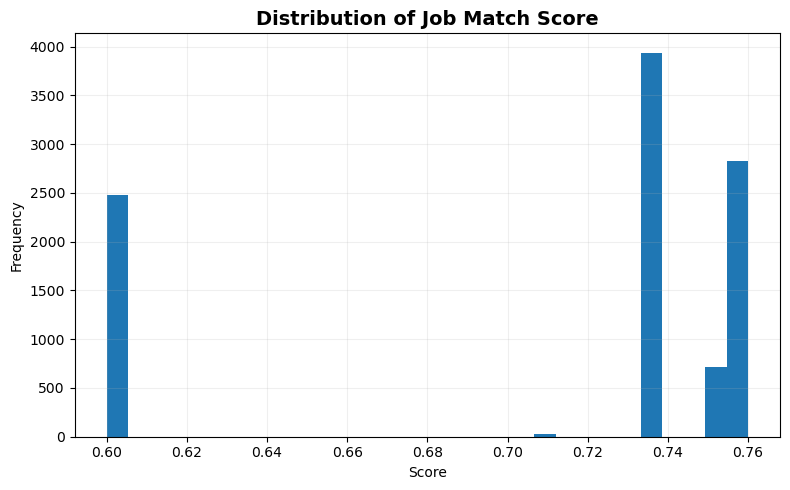

In [625]:
# Distribusi match score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(merged_df['match_score'], bins=30)

plt.title("Distribution of Job Match Score", fontsize=14, weight='bold')
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

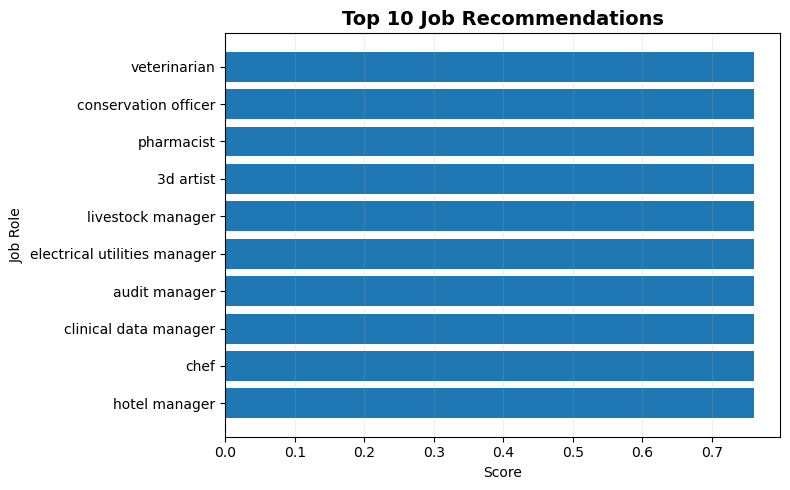

In [626]:
# Top 10 job reccommendation
top_jobs = merged_df.sort_values(by='match_score', ascending=False).head(10)

plt.figure(figsize=(8,5))
plt.barh(top_jobs['job_role'], top_jobs['match_score'])

plt.title("Top 10 Job Recommendations", fontsize=14, weight='bold')
plt.xlabel("Score")
plt.ylabel("Job Role")

plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.show()

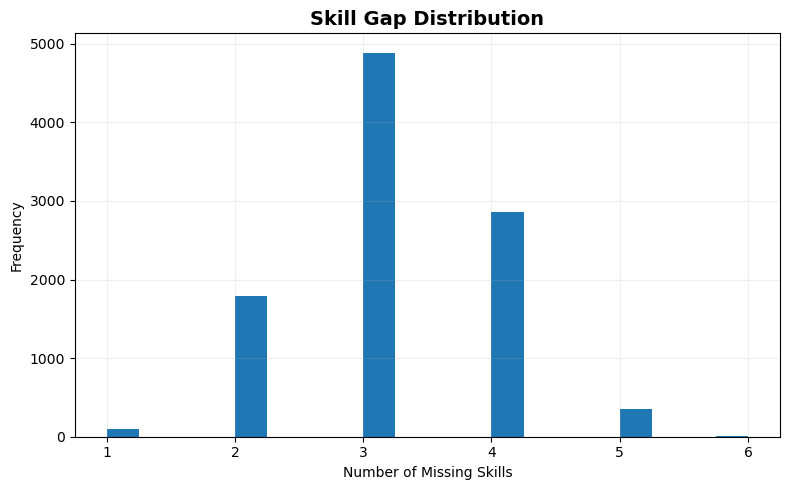

In [627]:
# Distribusi skill gap
gap_count = merged_df['skill_gap'].apply(len)

plt.figure(figsize=(8,5))
plt.hist(gap_count, bins=20)

plt.title("Skill Gap Distribution", fontsize=14, weight='bold')
plt.xlabel("Number of Missing Skills")
plt.ylabel("Frequency")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

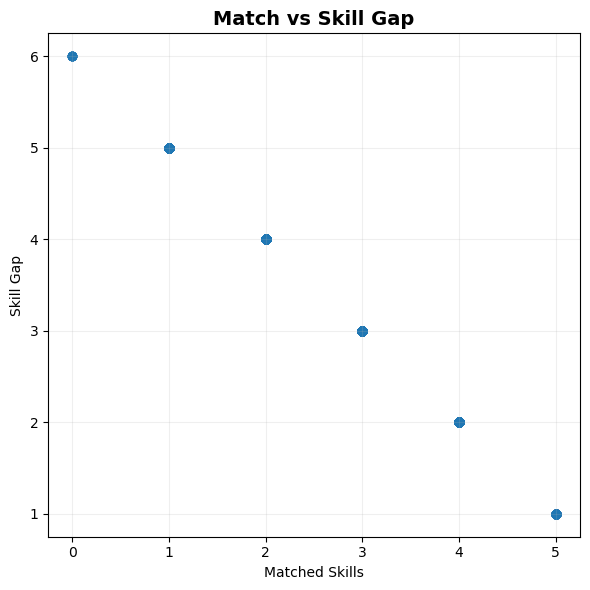

In [628]:
# Match VS Gap
match_count = merged_df['matched_skills'].apply(len)
gap_count = merged_df['skill_gap'].apply(len)

plt.figure(figsize=(6,6))
plt.scatter(match_count, gap_count)

plt.title("Match vs Skill Gap", fontsize=14, weight='bold')
plt.xlabel("Matched Skills")
plt.ylabel("Skill Gap")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

=== Top 10 Skill Gap ===
problem solving                : 2186
communication                  : 2173
leadership                     : 820
safety                         : 555
research                       : 501
customer service               : 459
sql                            : 446
creativity                     : 396
attention to detail            : 380
technical knowledge            : 343


C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\2784608112.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=gap_values, y=gap_names, palette="Blues_r", ax=ax)


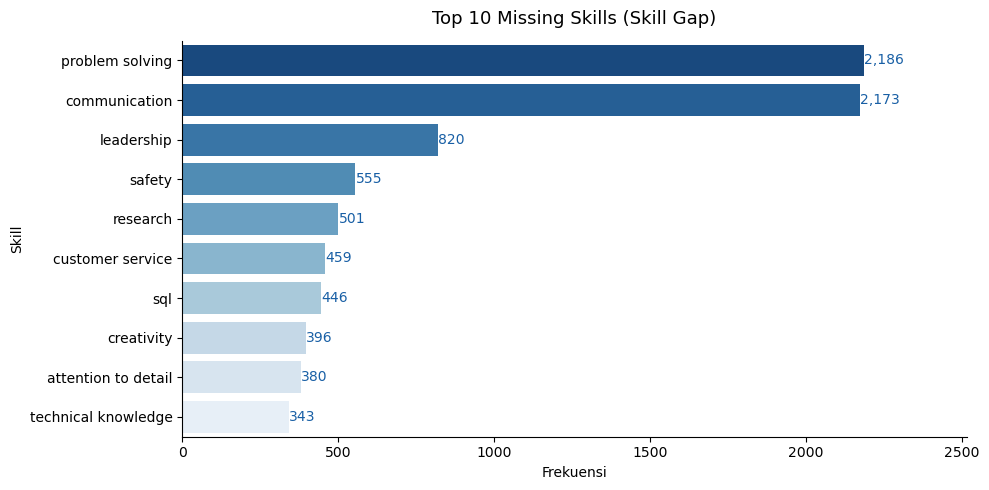

In [638]:
# Top skill gap pelamar
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil semua skill gap
all_gap_skills = merged_df['skill_gap'].explode()

# Hitung frekuensi
gap_counts = Counter(all_gap_skills)
top_gap = gap_counts.most_common(10)

# Data untuk plotting
gap_names = [s[0] for s in top_gap]
gap_values = [s[1] for s in top_gap]

print("=== Top 10 Skill Gap ===")
for skill, count in top_gap:
    print(f"{skill:<30} : {count}")

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(x=gap_values, y=gap_names, palette="Blues_r", ax=ax)

# Label angka di ujung bar
for bar, count in zip(ax.patches, gap_values):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va='center', ha='left', fontsize=10, color='#185FA5'
    )

ax.set_title("Top 10 Missing Skills (Skill Gap)", fontsize=13, pad=12)
ax.set_xlabel("Frekuensi")
ax.set_ylabel("Skill")
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(gap_values) * 1.15)

plt.tight_layout()
plt.show()

=== Top 10 Skill Pelamar ===
communication                  : 2103
problem solving                : 1912
leadership                     : 819
sql                            : 549
safety                         : 496
creativity                     : 489
research                       : 478
customer service               : 452
data analysis                  : 410
python                         : 364


C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\84967696.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=skill_counts, y=skill_names, palette="Blues_r", ax=ax)


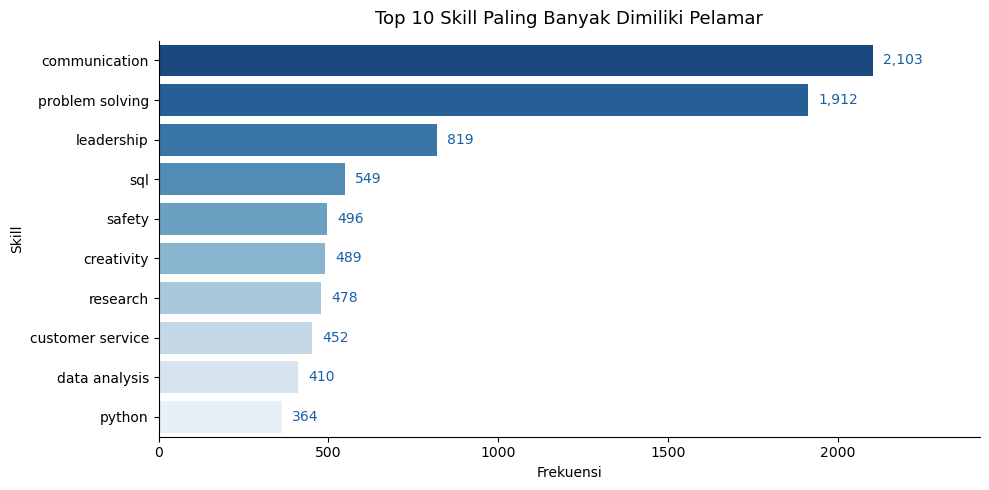

In [639]:
# Top 10 skill yang paling banyak dimiliki pelamar

all_candidate_skills = [s for lst in merged_df['skills'] for s in lst]
top_candidate_skills = Counter(all_candidate_skills).most_common(10)

print("=== Top 10 Skill Pelamar ===")
for skill, count in top_candidate_skills:
    print(f"{skill:<30} : {count}")

# Visualisasi
skill_names  = [s[0] for s in top_candidate_skills]
skill_counts = [s[1] for s in top_candidate_skills]

fig, ax = plt.subplots(figsize=(10, 5))
bars = sns.barplot(x=skill_counts, y=skill_names, palette="Blues_r", ax=ax)

# Label angka di ujung setiap bar
for i, (bar, count) in enumerate(zip(ax.patches, skill_counts)):
    ax.text(
        bar.get_width() + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va='center', ha='left', fontsize=10, color='#185FA5'
    )

ax.set_title("Top 10 Skill Paling Banyak Dimiliki Pelamar", fontsize=13, pad=12)
ax.set_xlabel("Frekuensi")
ax.set_ylabel("Skill")
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(skill_counts) * 1.15)  # beri ruang untuk label angka
plt.tight_layout()
plt.show()

Jumlah kategori unik : 42


C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\2067484439.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


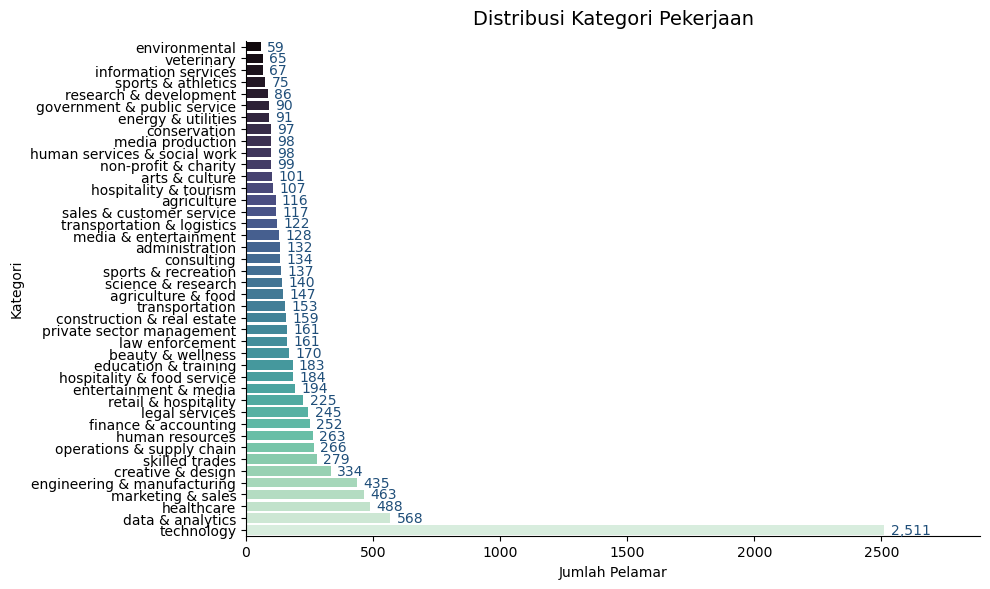

In [642]:
# Distribusi kategori pekerjaan (lebih readable)

category_counts = merged_df['category'].value_counts().sort_values(ascending=True)

print("Jumlah kategori unik :", merged_df['category'].nunique())

fig, ax = plt.subplots(figsize=(10, 6))

bars = sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    palette="mako",
    ax=ax
)

# Label angka di ujung bar
for bar, count in zip(ax.patches, category_counts.values):
    ax.text(
        bar.get_width() + max(category_counts.values)*0.01,
        bar.get_y() + bar.get_height()/2,
        f"{count:,}",
        va='center',
        ha='left',
        fontsize=10,
        color='#1f4e79'
    )

ax.set_title("Distribusi Kategori Pekerjaan", fontsize=14, pad=12)
ax.set_xlabel("Jumlah Pelamar")
ax.set_ylabel("Kategori")
ax.spines[['top', 'right']].set_visible(False)

ax.set_xlim(0, max(category_counts.values) * 1.15)

plt.tight_layout()
plt.show()

C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\1741199386.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


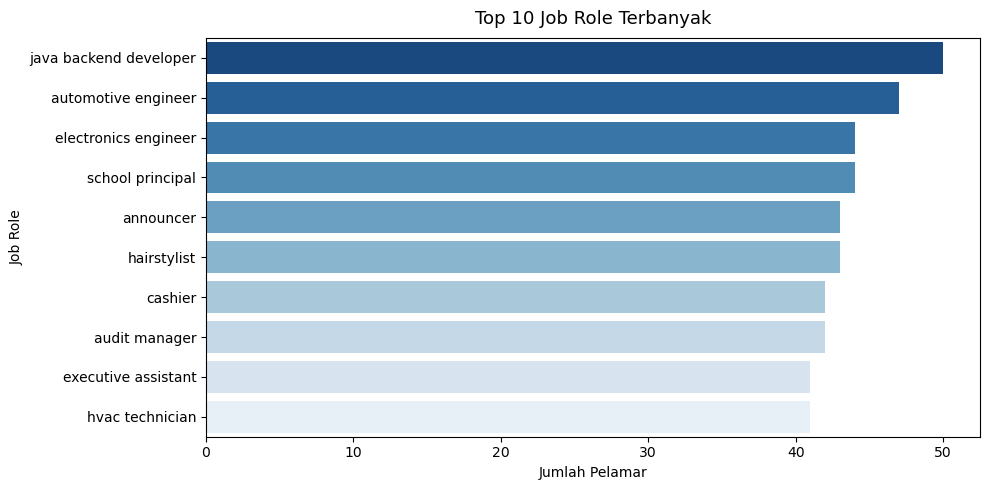

In [644]:
# Top 10 job role terbanyak (warna biru konsisten)
job_role_counts = merged_df['job_role'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=job_role_counts.values,
    y=job_role_counts.index,
    palette="Blues_r"
)

plt.title("Top 10 Job Role Terbanyak", fontsize=13, pad=10)
plt.xlabel("Jumlah Pelamar")
plt.ylabel("Job Role")

plt.tight_layout()
plt.show()

C:\Users\joyce\AppData\Local\Temp\ipykernel_11172\1061939298.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_counts.values, y=edu_counts.index, palette=colors)


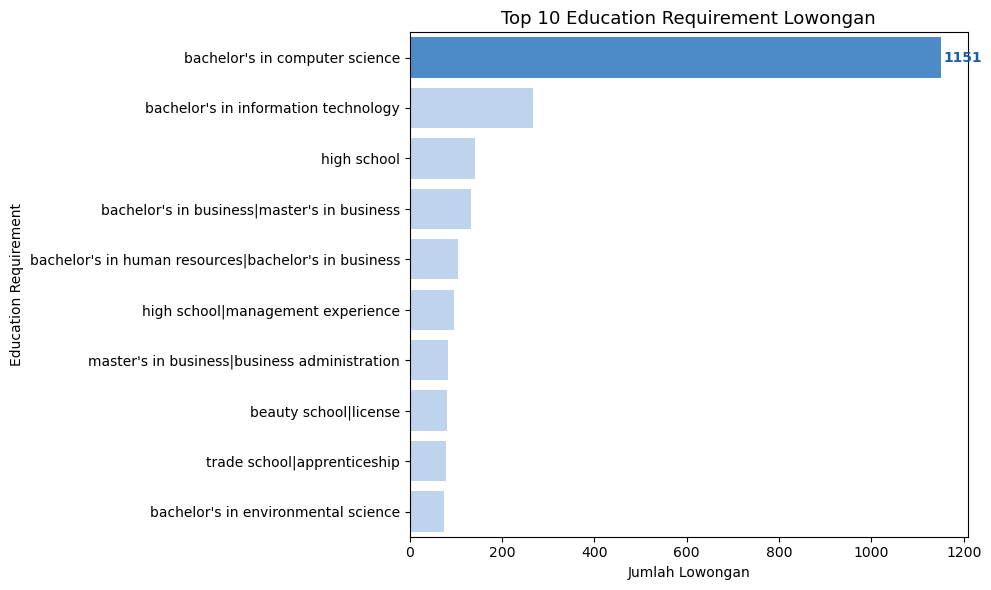

In [645]:
# Top 10 education requirement yang paling sering muncul
# Warna netral untuk semua bar, kecuali yang tertinggi diberi aksen
edu_counts = merged_df['education_requirement'].value_counts().head(10)

colors = ['#378ADD' if i == 0 else '#B5D4F4' for i in range(len(edu_counts))]

plt.figure(figsize=(10, 6))
sns.barplot(x=edu_counts.values, y=edu_counts.index, palette=colors)
plt.title("Top 10 Education Requirement Lowongan", fontsize=13)
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Education Requirement")

# Tambahkan label nilai di ujung bar tertinggi
plt.text(edu_counts.values[0] + 5, 0,
         str(edu_counts.values[0]),
         va='center', fontsize=10, fontweight='bold', color='#185FA5')

plt.tight_layout()
plt.show()

=== Kesesuaian Education Pelamar vs Lowongan ===
Match       : 2839 pelamar
Tidak match : 7161 pelamar
Match rate  : 28.39%


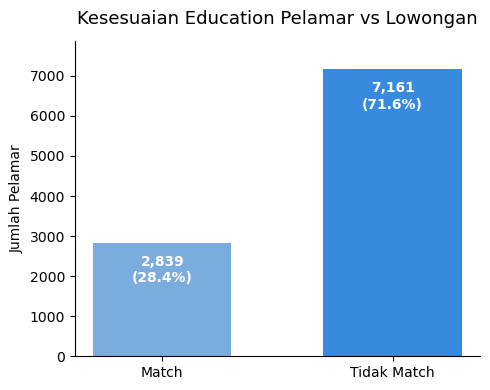

In [646]:
# Cek kesesuaian education pelamar vs lowongan
merged_df['education_match'] = merged_df['education'] == merged_df['education_requirement']

match_count   = merged_df['education_match'].sum()
nomatch_count = (~merged_df['education_match']).sum()
match_rate    = merged_df['education_match'].mean() * 100

print("=== Kesesuaian Education Pelamar vs Lowongan ===")
print(f"Match       : {match_count} pelamar")
print(f"Tidak match : {nomatch_count} pelamar")
print(f"Match rate  : {match_rate:.2f}%")

# Visualisasi barchart kesesuaian education
labels = ['Match', 'Tidak Match']
values = [match_count, nomatch_count]
colors = ["#7BACDE", '#378ADD']

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, values, color=colors, width=0.6, edgecolor='none')

# Label jumlah + persentase di dalam bar (bukan di atas)
for bar, val in zip(bars, values):
    pct = val / len(merged_df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() - 300,
            f"{val:,}\n({pct:.1f}%)",
            ha='center', va='top', fontsize=10,
            color='white', fontweight='bold')

ax.set_title("Kesesuaian Education Pelamar vs Lowongan", fontsize=13, pad=12)
ax.set_ylabel("Jumlah Pelamar")
ax.set_ylim(0, max(values) * 1.1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [649]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   resume_id              10000 non-null  object 
 1   resume_text            10000 non-null  object 
 2   skills                 10000 non-null  object 
 3   job_role               10000 non-null  object 
 4   education              10000 non-null  object 
 5   category               10000 non-null  object 
 6   required_skills        10000 non-null  object 
 7   education_requirement  10000 non-null  object 
 8   soft_skills_user       10000 non-null  object 
 9   hard_skills_user       10000 non-null  object 
 10  soft_skills_req        10000 non-null  object 
 11  hard_skills_req        10000 non-null  object 
 12  soft_skills_match      10000 non-null  object 
 13  hard_skills_match      10000 non-null  object 
 14  match_score            10000 non-null  float64
 15  ski

## MEMBUAT MODEL BASELINE